<a href="https://colab.research.google.com/github/AnnaZapototska/goit-colab-homeworks/blob/development/hw_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task

In [35]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from numpy.linalg import inv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix


In [36]:
def g(x_test, X_class, X_cov, X_inv_cov, X_prob):
    cov_det = np.linalg.det(X_cov)
    log_cov_det = np.log(cov_det)
    x_mean = np.reshape(np.mean(X_class, axis=0), (np.shape(X_class)[1], 1))
    diff = x_test.reshape(-1, 1) - x_mean
    g_i = -0.5 * diff.T @ X_inv_cov @ diff - 0.5 * log_cov_det + np.log(X_prob)
    return g_i

def g_matrix(X_test, X_class, X_cov, X_inv_cov, X_prob):
    g_val = []
    g_proba = []
    for i in range(len(X_test)):
        x_test = X_test[i]
        g_0 = g(x_test, X_class[0], X_cov[0], X_inv_cov[0], X_prob[0])
        g_1 = g(x_test, X_class[1], X_cov[1], X_inv_cov[1], X_prob[1])
        g_2 = g(x_test, X_class[2], X_cov[2], X_inv_cov[2], X_prob[2])
        g_i = np.array([g_0[0][0], g_1[0][0], g_2[0][0]])
        likelihood = np.exp(g_i - np.max(g_i))
        res = likelihood / np.sum(likelihood)
        g_val.append(g_i)
        g_proba.append(res)
    return np.array(g_val), np.array(g_proba)


In [37]:
iris = load_iris()

df = pd.DataFrame(
    data=iris.data,
    columns=iris.feature_names
)
df['species'] = [iris.target_names[i] for i in iris.target]

print("Basic Statistic Information:")
df.describe()

Basic Statistic Information:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [38]:
features = iris.data
labels = iris.target

features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training set shape:", features_train.shape)
print("Test set shape:", features_test.shape)

Training set shape: (120, 4)
Test set shape: (30, 4)


In [39]:
class_0 = features_train[labels_train == 0]
class_1 = features_train[labels_train == 1]
class_2 = features_train[labels_train == 2]

print("Class 0 shape:", class_0.shape)
print("Class 1 shape:", class_1.shape)
print("Class 2 shape:", class_2.shape)

Class 0 shape: (40, 4)
Class 1 shape: (40, 4)
Class 2 shape: (40, 4)


In [40]:
eps = 1e-6

cov_0 = np.cov(class_0, rowvar=False) + eps * np.eye(class_0.shape[1])
cov_1 = np.cov(class_1, rowvar=False) + eps * np.eye(class_1.shape[1])
cov_2 = np.cov(class_2, rowvar=False) + eps * np.eye(class_2.shape[1])

print("\nCovariance matrix for Class 0:")
print(cov_0)

print("\nCovariance matrix for Class 1:")
print(cov_1)

print("\nCovariance matrix for Class 2:")
print(cov_2)


Covariance matrix for Class 0:
[[0.09515485 0.09535897 0.00965385 0.01238462]
 [0.09535897 0.15925741 0.01547436 0.01146154]
 [0.00965385 0.01547436 0.02589203 0.00614103]
 [0.01238462 0.01146154 0.00614103 0.01330869]]

Covariance matrix for Class 1:
[[0.22728305 0.06538462 0.14992308 0.04092308]
 [0.06538462 0.09538562 0.06269231 0.03358974]
 [0.14992308 0.06269231 0.19640485 0.06046154]
 [0.04092308 0.03358974 0.06046154 0.03497536]]

Covariance matrix for Class 2:
[[0.46912921 0.11302564 0.35123077 0.04882051]
 [0.11302564 0.12523177 0.09394872 0.05235897]
 [0.35123077 0.09394872 0.33189844 0.05876923]
 [0.04882051 0.05235897 0.05876923 0.07220613]]


In [41]:
inv_cov_0 = np.linalg.inv(cov_0)
inv_cov_1 = np.linalg.inv(cov_1)
inv_cov_2 = np.linalg.inv(cov_2)

print("\nInverse covariance matrix for Class 0:")
print(inv_cov_0)

print("\nInverse covariance matrix for Class 1:")
print(inv_cov_1)

print("\nInverse covariance matrix for Class 2:")
print(inv_cov_2)


Inverse covariance matrix for Class 0:
[[ 28.19799154 -16.14436069   2.31425858 -13.40432148]
 [-16.14436069  16.14514123  -4.37380614   3.13728767]
 [  2.31425858  -4.37380614  44.90489012 -19.10726695]
 [-13.40432148   3.13728767 -19.10726695  93.72727313]]

Inverse covariance matrix for Class 1:
[[  9.67054298  -3.3975462   -8.16225903   6.0578955 ]
 [ -3.3975462   17.09350425   2.0671489  -16.01445701]
 [ -8.16225903   2.0671489   17.81261527 -23.2274491 ]
 [  6.0578955  -16.01445701 -23.2274491   77.03655279]]

Inverse covariance matrix for Class 2:
[[ 11.27261528  -3.08370864 -11.80385682   4.22164373]
 [ -3.08370864  13.66602298   0.91189897  -8.56689489]
 [-11.80385682   0.91189897  16.29917498  -5.946389  ]
 [  4.22164373  -8.56689489  -5.946389    22.04682297]]


In [42]:
prior_0 = np.sum(labels_train == 0) / len(labels_train)
prior_1 = np.sum(labels_train == 1) / len(labels_train)
prior_2 = np.sum(labels_train == 2) / len(labels_train)

print("Prior probability of class 0:", prior_0)
print("Prior probability of class 1:", prior_1)
print("Prior probability of class 2:", prior_2)

Prior probability of class 0: 0.3333333333333333
Prior probability of class 1: 0.3333333333333333
Prior probability of class 2: 0.3333333333333333


In [43]:
mean_0 = np.mean(class_0, axis=0)
mean_1 = np.mean(class_1, axis=0)
mean_2 = np.mean(class_2, axis=0)

x = features_test[6]

def discriminant(x, mean, inv_cov, cov, prior):
    diff = x - mean
    sign, log_det = np.linalg.slogdet(cov)

    g = (
        -0.5 * diff.T @ inv_cov @ diff
        -0.5 * log_det
        + np.log(prior)
    )

    return g


g0 = discriminant(x, mean_0, inv_cov_0, cov_0, prior_0)
g1 = discriminant(x, mean_1, inv_cov_1, cov_1, prior_1)
g2 = discriminant(x, mean_2, inv_cov_2, cov_2, prior_2)

print(g0)
print(g1)
print(g2)

-3.1898606601531068
-55.44806071335502
-98.20073582029576


In [44]:
values = []

for x in features_test:

    g0 = discriminant(x, mean_0, inv_cov_0, cov_0, prior_0)
    g1 = discriminant(x, mean_1, inv_cov_1, cov_1, prior_1)
    g2 = discriminant(x, mean_2, inv_cov_2, cov_2, prior_2)

    values.append([g0, g1, g2])

values = np.array(values)


likelihood = np.exp(values - values.max(axis=1)[:, np.newaxis])
probabilities = likelihood / likelihood.sum(axis=1)[:, np.newaxis]

probabilities

array([[1.00000000e+000, 4.95919600e-017, 2.11579168e-032],
       [3.04935121e-125, 1.70060375e-001, 8.29939625e-001],
       [4.02013214e-037, 9.99990932e-001, 9.06800690e-006],
       [1.25951223e-038, 9.99994126e-001, 5.87374937e-006],
       [1.00000000e+000, 1.34118506e-018, 9.81674822e-034],
       [1.16015796e-107, 9.94432540e-001, 5.56746027e-003],
       [1.00000000e+000, 2.01628576e-023, 5.46136493e-042],
       [1.00000000e+000, 1.15882628e-019, 8.21436793e-038],
       [6.32372922e-154, 1.49436377e-003, 9.98505636e-001],
       [4.40481785e-091, 9.49975841e-001, 5.00241587e-002],
       [1.52238341e-248, 7.03933820e-005, 9.99929607e-001],
       [1.80940747e-161, 8.49715875e-008, 9.99999915e-001],
       [1.19440457e-199, 3.46900604e-006, 9.99996531e-001],
       [1.87164542e-098, 9.99725200e-001, 2.74799659e-004],
       [1.00000000e+000, 8.62638855e-022, 4.40837288e-039],
       [1.00000000e+000, 2.77767967e-021, 1.10842705e-039],
       [1.00000000e+000, 2.79668442e-032

In [45]:
qda = QuadraticDiscriminantAnalysis()

qda.fit(features_train, labels_train)

prediction = qda.predict(features_test)
probability = qda.predict_proba(features_test)

for i in range(5):
    print(f"Sample {i+1}")
    print(f"True class      : {labels_test[i]}")
    print(f"Predicted class : {prediction[i]}")
    print(f"Probabilities   : {probability[i]}")
    print()

Sample 1
True class      : 0
Predicted class : 0
Probabilities   : [1.00000000e+00 4.95548717e-17 2.11335393e-32]

Sample 2
True class      : 2
Predicted class : 2
Probabilities   : [3.01573558e-125 1.70041108e-001 8.29958892e-001]

Sample 3
True class      : 1
Predicted class : 1
Probabilities   : [4.00677009e-37 9.99990934e-01 9.06645693e-06]

Sample 4
True class      : 1
Predicted class : 1
Probabilities   : [1.25517815e-38 9.99994127e-01 5.87269714e-06]

Sample 5
True class      : 0
Predicted class : 0
Probabilities   : [1.00000000e+00 1.34002718e-18 9.80522779e-34]



In [46]:
my_prediction = np.argmax(probabilities, axis=1)

for i in range(5):
    print(f"Object {i+1}")
    print(f"My prediction      : {my_prediction[i]}")
    print(f"Sklearn prediction : {prediction[i]}")
    print()

print("Do the predictions of the custom implementation match sklearn QDA?")
print(np.array_equal(my_prediction, prediction))

Object 1
My prediction      : 0
Sklearn prediction : 0

Object 2
My prediction      : 2
Sklearn prediction : 2

Object 3
My prediction      : 1
Sklearn prediction : 1

Object 4
My prediction      : 1
Sklearn prediction : 1

Object 5
My prediction      : 0
Sklearn prediction : 0

Do the predictions of the custom implementation match sklearn QDA?
True


In [47]:
print("Accuracy:", accuracy_score(labels_test, prediction))

Accuracy: 1.0


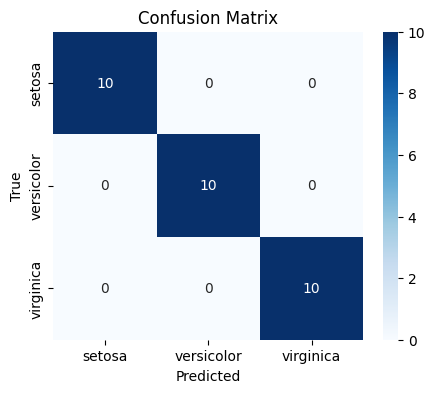

In [48]:
cm = confusion_matrix(labels_test, prediction)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

# Summary

The Quadratic Discriminant Analysis algorithm was implemented manually. For each class, the mean vectors, covariance matrices, their inverse matrices, and prior probabilities were calculated separately. Based on these values, a discriminant function was implemented and the probabilities of test objects belonging to each class were calculated.

The results obtained were compared with the library implementation of QuadraticDiscriminantAnalysis from sklearn. The predictions of our own implementation coincided with the library results, which confirms the correctness of the algorithm implementation.

The error matrix showed that the model correctly classified all test objects. For each of the three classes (Setosa, Versicolor and Virginica), 10 correct predictions and no errors were obtained. Thus, the classification accuracy on the test sample is 100%.